# Isolated finger

### SENG

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy

In [9]:
def call_dataset(path, subj, modality, session):
    path = path + subj + '/'
    if modality=='EMG':
        bluetooth_id = 'E8DD80E550BB'
    elif modality=='ENG':
        bluetooth_id = 'E9AD0E7DCC2B'
    else:
        print("modality must be EMG or ENG")

    dataset = []
    data_per_class_files = os.listdir(path+f'{bluetooth_id}/raw/')
    for cls in data_per_class_files:
        input_path = path+f'{bluetooth_id}/raw/{cls}/'
        files = os.listdir(input_path)
        mat = scipy.io.loadmat(input_path+files[0])
        #dict_keys(['__header__', '__version__', '__globals__', 'Data_ADC', 'Data_Cls', 'Data_Fea', 'Dev_Channels', 'Dev_Info', 'Dev_NCh'])
        dataset.append(mat)

    return dataset

In [11]:
path = 'C:/Users/hml76/PycharmProjects/MindForce/data/sENG_iENG/'
subject_names = os.listdir(path)

subjects_ENG = []

for i in subject_names:
    ENG_all = call_dataset(path, subj=i, modality='ENG', session='v1')
    subjects_ENG.append(ENG_all)

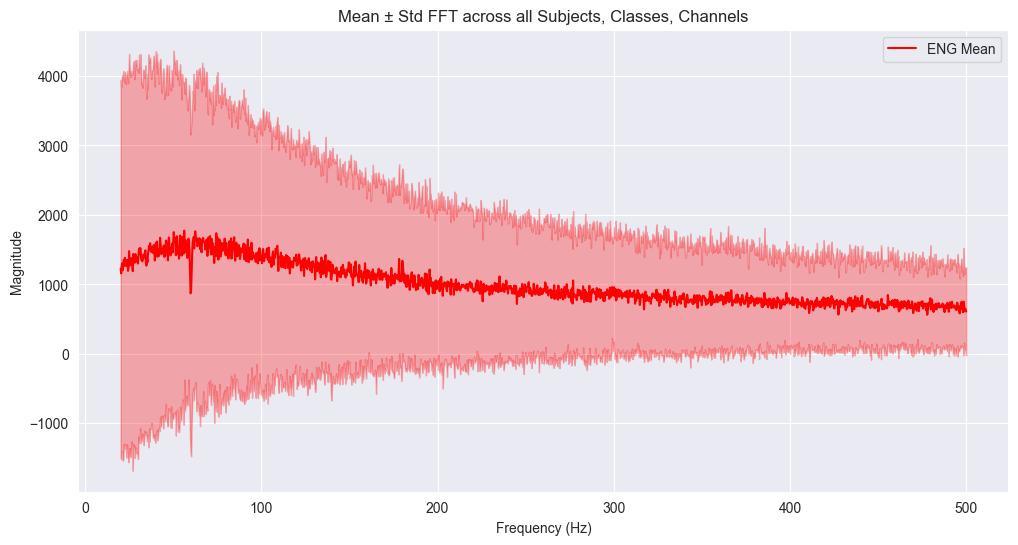

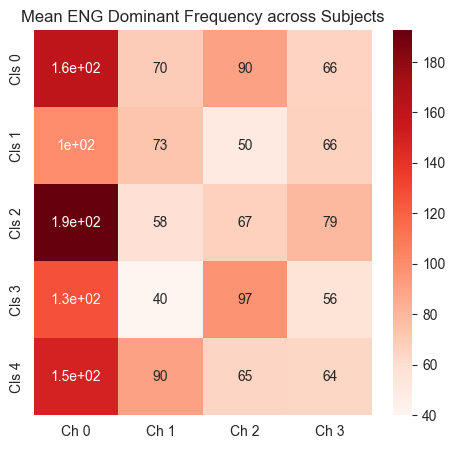

In [14]:
fs = round(10e6 / 2048)
num_subjects = 3
num_classes = 5
num_channels = len(ENG_all[0]['Data_ADC'])

freq_min, freq_max = 20, 500
fft_len = 2**14  # zero-padding

# Dominant frequency matrix for all subjects
eng_dom_band_all = np.zeros((num_subjects, num_classes, num_channels))

# Mean FFT across all subjects, classes, channels
all_freqs = None
eng_all_fft = []

for s_idx in range(num_subjects):
    ENG_all = subjects_ENG[s_idx]

    for cls in range(num_classes):
        for ch in range(num_channels):
            # DC 제거
            eng_signal = ENG_all[cls]['Data_ADC'][ch] - np.mean(ENG_all[cls]['Data_ADC'][ch])

            # FFT
            eng_fft = np.fft.fft(eng_signal, n=fft_len)
            freqs = np.fft.fftfreq(len(eng_fft), d=1/fs)

            # 주파수 범위 필터
            pos_mask = (freqs > 0) & (freqs >= freq_min) & (freqs <= freq_max)
            freqs = freqs[pos_mask]
            eng_fft_mag = np.abs(eng_fft[pos_mask])

            # Dominant frequency 저장
            eng_dom_band_all[s_idx, cls, ch] = freqs[np.argmax(eng_fft_mag)]

            # 전체 FFT 저장
            eng_all_fft.append(eng_fft_mag)

    # freqs는 동일하므로 한 번만 저장
    if all_freqs is None:
        all_freqs = freqs

eng_all_fft = np.array(eng_all_fft)

# 평균 ± 표준편차 계산
eng_mean_fft = np.mean(eng_all_fft, axis=0)
eng_std_fft = np.std(eng_all_fft, axis=0)

# --- Visualization ---

# 1. Mean ± Std Spectrum
plt.figure(figsize=(12,6))
plt.plot(all_freqs, eng_mean_fft, color='red', label='ENG Mean')
plt.fill_between(all_freqs, eng_mean_fft-eng_std_fft, eng_mean_fft+eng_std_fft, color='red', alpha=0.3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Mean ± Std FFT across all Subjects, Classes, Channels')
plt.legend()
plt.show()

# 2. Dominant Frequency Heatmap (subjects x classes x channels)

'''for s_idx in range(num_subjects):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    sns.heatmap(eng_dom_band_all[s_idx], annot=True, cmap='Reds', xticklabels=[f'Ch {i}' for i in range(num_channels)],
                yticklabels=[f'Cls {i}' for i in range(num_classes)])
    plt.title(f'Subject {s_idx+1} ENG Dominant Frequency (Hz)')

    plt.subplot(1,2,2)
    sns.heatmap(emg_dom_band_all[s_idx], annot=True, cmap='Blues', xticklabels=[f'Ch {i}' for i in range(num_channels)],
                yticklabels=[f'Cls {i}' for i in range(num_classes)])
    plt.title(f'Subject {s_idx+1} EMG Dominant Frequency (Hz)')
    plt.show()
'''
# 3. 전체 subjects 평균 dominant frequency per class-channel
eng_mean_dom = np.mean(eng_dom_band_all, axis=0)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.heatmap(eng_mean_dom, annot=True, cmap='Reds', xticklabels=[f'Ch {i}' for i in range(num_channels)],
            yticklabels=[f'Cls {i}' for i in range(num_classes)])
plt.title('Mean ENG Dominant Frequency across Subjects')
plt.show()


ENG dominant frequency variance: 3477.94 Hz^2


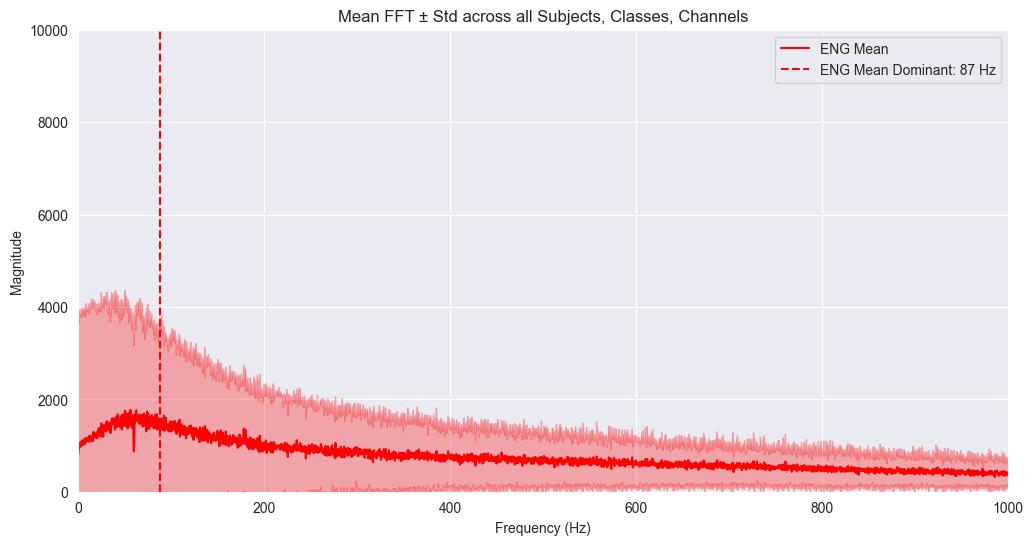

In [16]:
fs = round(10e6 / 2048)
fft_len = 2**14
num_classes = 5

# Store FFT magnitudes and dominant frequencies
eng_all_fft = []
eng_dom_freqs = []

for s_idx in range(num_subjects):
    ENG_all = subjects_ENG[s_idx]

    for cls in range(num_classes):
        for ch in range(num_channels):
            # DC removal
            eng_signal = ENG_all[cls]['Data_ADC'][ch] - np.mean(ENG_all[cls]['Data_ADC'][ch])

            # FFT
            eng_fft = np.fft.fft(eng_signal, n=fft_len)
            freqs = np.fft.fftfreq(len(eng_fft), d=1/fs)
            pos_mask = freqs > 0
            freqs = freqs[pos_mask]

            eng_fft_mag = np.abs(eng_fft[pos_mask])

            # Store FFT magnitudes
            eng_all_fft.append(eng_fft_mag)

            # Store dominant frequencies
            eng_dom_freqs.append(freqs[np.argmax(eng_fft_mag)])

# Convert to arrays
eng_all_fft = np.array(eng_all_fft)
eng_dom_freqs = np.array(eng_dom_freqs)

# Mean, Std, Variance
eng_mean_fft = np.mean(eng_all_fft, axis=0)
eng_std_fft = np.std(eng_all_fft, axis=0)
eng_var_fft = np.var(eng_all_fft, axis=0)

# Variance of dominant frequency across all subjects/classes/channels
eng_dom_var = np.var(eng_dom_freqs)
print(f'ENG dominant frequency variance: {eng_dom_var:.2f} Hz^2')

fig, axes = plt.subplots(1, 1, figsize=(12, 6))

for signal_type, mean_fft, std_fft, dom_freq, color in zip(
    ['ENG'],
    [eng_mean_fft],
    [eng_std_fft],
    [np.mean(eng_dom_freqs)],
    ['red','blue']
):
    axes.plot(freqs, mean_fft, label=f'{signal_type} Mean', color=color)
    axes.fill_between(freqs, mean_fft-std_fft, mean_fft+std_fft, color=color, alpha=0.3)
    axes.axvline(dom_freq, color=color, linestyle='--', label=f'{signal_type} Mean Dominant: {int(dom_freq)} Hz')

axes.set_xlabel('Frequency (Hz)')
axes.set_ylabel('Magnitude')
axes.set_title('Mean FFT ± Std across all Subjects, Classes, Channels')
axes.legend()
axes.set_ylim(0,10000)
axes.set_xlim(0,1000)
plt.show()